In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

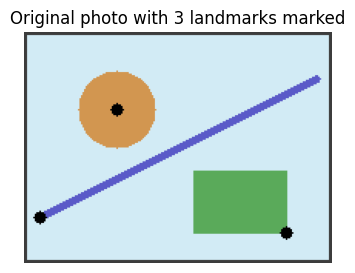

In [2]:
def make_photo(w=200, h=150):
    img = np.full((h, w, 3), (245, 235, 210), dtype=np.uint8)
    cv2.rectangle(img, (0, 0), (w - 1, h - 1), (60, 60, 60), 2)
    cv2.circle(img, (60, 50), 25, (80, 150, 210), -1)
    cv2.rectangle(img, (110, 90), (170, 130), (90, 170, 90), -1)
    cv2.line(img, (10, 120), (190, 30), (200, 90, 90), 3)
    landmarks = {'eye': (60, 50), 'corner': (170, 130), 'origin': (10, 120)}
    for name, (x, y) in landmarks.items():
        cv2.circle(img, (x, y), 4, (0, 0, 0), -1)
    return img, landmarks

photo, landmarks = make_photo()
cv2.imwrite('data_photo.png', photo)
plt.figure(figsize=(4, 3))
plt.imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
plt.title('Original photo with 3 landmarks marked')
plt.axis('off')
plt.savefig('output/00_original.png', bbox_inches='tight', dpi=150)
plt.show()

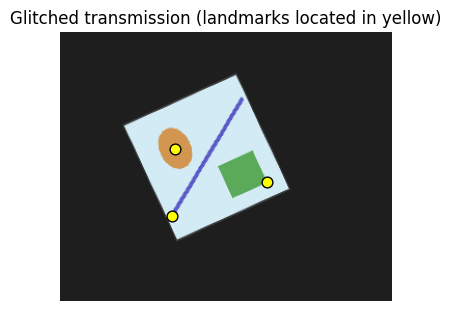

In [3]:
h, w = photo.shape[:2]
canvas_w, canvas_h = 320, 260

true_glitch = np.array([
    [0.55, 0.35, 60],
    [-0.25, 0.75, 90]
])

glitched = cv2.warpAffine(photo, true_glitch, (canvas_w, canvas_h), borderValue=(30, 30, 30))

src_pts = np.array([landmarks['eye'], landmarks['corner'], landmarks['origin']], dtype=np.float64)
ones = np.ones((3, 1))
dst_pts = (true_glitch @ np.hstack([src_pts, ones]).T).T

plt.figure(figsize=(4.5, 3.5))
plt.imshow(cv2.cvtColor(glitched, cv2.COLOR_BGR2RGB))
for (x, y) in dst_pts:
    plt.scatter([x], [y], c='yellow', edgecolors='black', s=60, zorder=5)
plt.title('Glitched transmission (landmarks located in yellow)')
plt.axis('off')
plt.savefig('output/01_glitched.png', bbox_inches='tight', dpi=150)
plt.show()

Linear system A =
 [[110.5 112.5   0.    0.    1.    0. ]
 [  0.    0.  110.5 112.5   0.    1. ]
 [199.  145.    0.    0.    1.    0. ]
 [  0.    0.  199.  145.    0.    1. ]
 [107.5 177.5   0.    0.    1.    0. ]
 [  0.    0.  107.5 177.5   0.    1. ]]
Right-hand side b = [ 60.  50. 170. 130.  10. 120.]
Solved unknowns [a, b, c, d, e, f] = [   1.5   -0.7    0.5    1.1  -27.  -129. ]
Recovered affine matrix M_fix =
 [[   1.5   -0.7  -27. ]
 [   0.5    1.1 -129. ]]


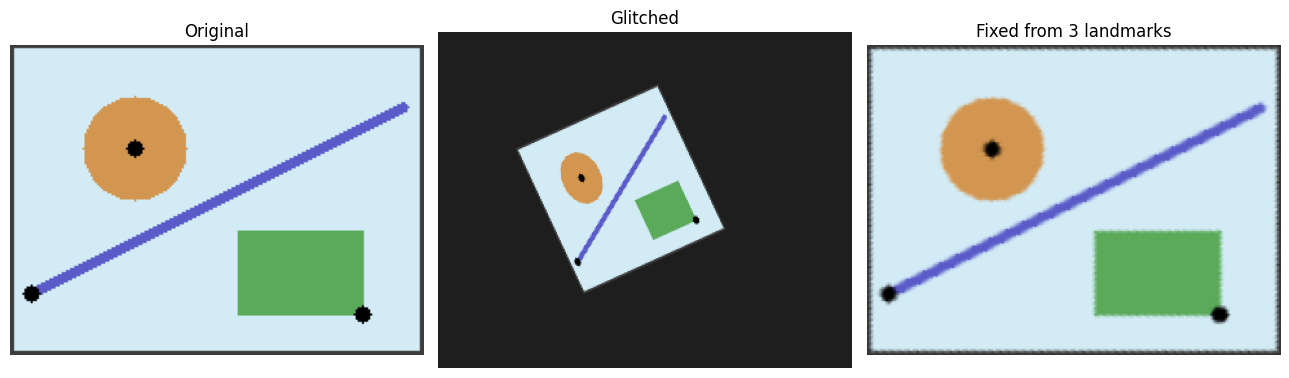

In [4]:
A = np.zeros((6, 6))
b = np.zeros(6)
for i in range(3):
    gx, gy = dst_pts[i]
    ox, oy = src_pts[i]
    A[2 * i]     = [gx, gy, 0, 0, 1, 0]
    A[2 * i + 1] = [0, 0, gx, gy, 0, 1]
    b[2 * i]     = ox
    b[2 * i + 1] = oy

print('Linear system A =\n', A)
print('Right-hand side b =', b)

solution = np.linalg.solve(A, b)
a_, b_, c_, d_, e_, f_ = solution
print('Solved unknowns [a, b, c, d, e, f] =', solution)

M_fix = np.array([
    [a_, b_, e_],
    [c_, d_, f_]
])
print('Recovered affine matrix M_fix =\n', M_fix)

fixed_photo = cv2.warpAffine(glitched, M_fix, (w, h), borderValue=(30, 30, 30))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(glitched, cv2.COLOR_BGR2RGB))
axes[1].set_title('Glitched')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(fixed_photo, cv2.COLOR_BGR2RGB))
axes[2].set_title('Fixed from 3 landmarks')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/02_fixed.png', bbox_inches='tight', dpi=150)
plt.show()